In [1]:
import torch
import numpy as np
from datasets import load_dataset,DatasetDict, Dataset
import os
import time
import math
import tiktoken
import sys
import numpy as np
from tqdm.auto import tqdm
from transformers import GPT2Tokenizer
import json
import argparse

from contextlib import nullcontext

In [2]:
RELOAD_DATA_WIKI = False
RELOAD_DATA_TINY = False
dataset_train_wiki = False
dataset_train_tinystories = True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
original_dir = os.getcwd()
work_dir = "/content/drive/MyDrive/DiffusionLLMs/"

In [5]:
sys.path.append(work_dir)
os.chdir(work_dir)

In [6]:
from sinusoidal_position import SinusoidalPosition
from ssharma_gpt import GPTModel
import matplotlib.pyplot as plt
import pickle

In [7]:
os.chdir(original_dir)

In [8]:
if RELOAD_DATA_WIKI:
    ds_wiki = load_dataset(
      "Salesforce/wikitext",
      "wikitext-103-v1"
      )["train"]

    lines = []
    for entry in ds_wiki:
      text = entry["text"]
      text = text.replace("\n", " ") # remove newline formattin
      text = " ".join(text.split()) # remove sequences of whitespace
      lines.append(text+"\n")

    os.makedirs("/content/drive/MyDrive/DiffusionLLMs/", exist_ok=True)

    with open("/content/drive/MyDrive/DiffusionLLMs/data.txt", "w") as f:
        f.writelines(lines)
    f.close

In [9]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [10]:
def tokenize_function(examples):
    outputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512
    )
    return {
        "ids": outputs["input_ids"],
        "len": [len(x) for x in outputs["input_ids"]]
    }

In [11]:
def create_tokenized_binary_file(tokenized_input,dataset_name):
  os.makedirs(work_dir, exist_ok=True)

  if isinstance(tokenized_input, Dataset):
        # Default split name if a single Dataset is passed
        items_to_process = {"train": tokenized_input}
  elif isinstance(tokenized_input, DatasetDict):
        items_to_process = tokenized_input.items()
  elif isinstance(tokenized_input, dict):
        items_to_process = tokenized_input.items()
  else:
        raise TypeError(f"Unsupported dataset type: {type(tokenized_input)}")

  for split, dset in tokenized_input.items():
        filename = os.path.join(work_dir, f"{dataset_name}_{split}.bin")

        # Check existence per-split file
        if os.path.exists(filename):
            print(f"Skipping {filename} (already exists. overwriting)")
        arr_len = np.sum(dset['len'], dtype=np.uint64)

        dtype = np.uint16 # (can do since enc.max_token_value == 50256 is < 2**16)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # Batch together samples for faster write
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            # Write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

In [12]:
if RELOAD_DATA_WIKI:
  # First split: 80% train, 20% temp (which will become val + test)
  ds_split1 = ds_wiki.train_test_split(test_size=0.2, seed=42)

  # Second split: Split the 20% temp evenly into 10% val and 10% test
  ds_split2 = ds_split1['test'].train_test_split(test_size=0.5, seed=42)

  ds_wiki_3splits = DatasetDict({
    'train': ds_split1['train'],
    'val': ds_split2['train'],
    'test': ds_split2['test']
  })

In [13]:
if RELOAD_DATA_WIKI:
  tokenized_ds_wiki = ds_wiki_3splits.map(
      tokenize_function,
      batched=True,
      num_proc=8,
      remove_columns=["text"]
  )

In [14]:
if RELOAD_DATA_WIKI:
  create_tokenized_binary_file(tokenized_ds_wiki, "wiki")

In [15]:
if RELOAD_DATA_TINY:
    ds_tiny = load_dataset("roneneldan/TinyStories")

    # Extract train, validation, and test splits
    # TinyStories has 'train' and 'validation'; we can split validation into val and test
    val_test_split = ds_tiny['validation'].train_test_split(test_size=0.5, seed=42)
    ds_tiny_3splits = DatasetDict({
        'train': ds_tiny['train'],
        'val': val_test_split['train'],
        'test': val_test_split['test']
    })

    # Tokenize splits
    tokenized_ds_tiny = ds_tiny_3splits.map(
        tokenize_function,
        batched=True,
        num_proc=8,
        remove_columns=["text"]
    )

    # Save mmap binary files as 'tinystories_train.bin', etc.
    create_tokenized_binary_file(tokenized_ds_tiny, "tinystories")

## GPT Model
This model can be configured either as a Autoregressive or as a Diffusion based model

In [16]:
def get_config():
    config_filename = os.path.join(work_dir,"llm_config.json")
    try:
        with open(config_filename, 'r') as config_file:
            config_data = json.load(config_file)
            return config_data

    except FileNotFoundError:
        print("Error: llm_config.json not found.")
        return None

In [17]:
def get_positional_embedding(config_data):
    positional_embedding = config_data['llm_config']['positional_embedding']
    print(positional_embedding)
    return positional_embedding

In [18]:
def get_device_and_precision():
    """Selects target hardware device, precision dtype, autocast context, and gradient scaler."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    device_type = "cuda" if "cuda" in device else "cpu"

    dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
    ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

    ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)
    if device_type == 'cpu':
        scaler = torch.amp.GradScaler(enabled=False)
    else:
      scaler = torch.amp.GradScaler(enabled=(dtype == 'float16'))

    print(f"Using device: {device} | Precision: {dtype}")
    return device, dtype, ctx, scaler

In [19]:
def init_model(config_data):
    llm_type = config_data['llm_config'].get('LLM_type') or config_data['llm_config'].get('llm_type')
    print("LLM Type ",llm_type)
    config_data["llm_config"]["vocab_size"] = 50257 # Hardcoded
    positional_embedding=get_positional_embedding(config_data)
    d_model = config_data['llm_config']['d_model']
    max_seq_len=config_data['llm_config']['max_seq_len']
    n_heads = config_data['llm_config']['n_heads']
    num_layers=config_data['llm_config']['num_layers']
    vocab_size=config_data['llm_config']['vocab_size']
    attention_type=config_data['llm_config']['attention']
    theta=config_data['llm_config']['theta']
    print("Theta for Rotary Embedings ",theta)
    ffn_hidden_dim=config_data['llm_config']['ffn_hidden_dim']
    ffn_hidden_dim=int(ffn_hidden_dim)
    print("FFN Hidden Dim ",ffn_hidden_dim)
    if llm_type=="Autoregressive":
      activation="relu"
    else:
      activation="gelu"
    print("Activation ",activation)
    if llm_type=="Diffusion":
      diffusion_steps=config_data['llm_config'].get('diffusion_steps')
      print("Diffusion Steps ",diffusion_steps)
      config_data['llm_config']['diffusion_steps']=diffusion_steps
      model = GPTModel(d_model, n_heads, num_layers, vocab_size, max_seq_len,\
                     positional_embedding,theta,attention_type,ffn_hidden_dim,llm_type,activation,diffusion_steps)
    else:
      model = GPTModel(d_model, n_heads, num_layers, vocab_size, max_seq_len,\
                     positional_embedding,theta,attention_type,ffn_hidden_dim,llm_type,activation)
    param_count = sum(p.numel() for p in model.parameters())
    print("Model has", param_count, "parameters.")
    return model

In [20]:
def get_batch(split, dataset_dir, dataset_name, block_size, batch_size, device):
    """Fetches a batch of input (x) and target (y) sequences from binary files."""
    filename = os.path.join(dataset_dir, f"{dataset_name}_{split}.bin")
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Binary dataset not found at {filename}")

    data = np.memmap(filename, dtype=np.uint16, mode='r')

    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])

    return x.to(device), y.to(device)

## Diffusion Model Masking & Loss Computation

In [37]:
def mask_ratio_schedule(t, T: int):
    # Linear schedule: ratio = t/T
    return t.float() / float(T)


In [ ]:
@torch.no_grad()
def corrupt_with_mask(input_ids, attention_mask, t, mask_token_id: int, T: int):
    # Returns noisy_ids, labels, mask_positions
    B, L = input_ids.shape
    ratio = mask_ratio_schedule(t, T).unsqueeze(1)  # [B,1]

    can_mask = attention_mask.clone()
    can_mask &= (input_ids != BOS_ID) & (input_ids != EOS_ID) & (input_ids != PAD_ID)

    rand = torch.rand((B, L), device=input_ids.device)
    mask_positions = (rand < ratio) & can_mask

    noisy = input_ids.clone()
    noisy[mask_positions] = mask_token_id

    labels = torch.full_like(input_ids, -100)
    labels[mask_positions] = input_ids[mask_positions]

    return noisy, labels, mask_positions

In [ ]:
@torch.no_grad()
def diffusion_loss(model, batch, T: int):
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]

    B = input_ids.size(0)
    t = torch.randint(1, T + 1, (B,), device=input_ids.device)

    noisy_ids, labels, _ = corrupt_with_mask(
        input_ids=input_ids,
        attention_mask=attention_mask,
        t=t,
        mask_token_id=MASK_ID,
        T=T,
    )

    logits = model(noisy_ids, timesteps=t, attention_mask=attention_mask)  # [B,L,V]
    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        labels.view(-1),
        ignore_index=-100,
    )
    return loss

In [21]:
@torch.no_grad()
def estimate_loss(model, eval_iters, dataset_dir, dataset_name, block_size, batch_size, device, ctx):
    """Evaluates loss across train and val splits without calculating gradients."""
    out = {}
    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X_eval, Y_eval = get_batch(split, dataset_dir, dataset_name, block_size, batch_size, device)
            with ctx:
                logits, loss = model(X_eval, targets=Y_eval) if hasattr(model, 'targets') else (model(X_eval), None)
                if loss is None:
                    loss = torch.nn.functional.cross_entropy(logits.view(-1, logits.size(-1)), Y_eval.view(-1))
            losses[k] = loss.item()
        out[split] = losses.mean()

    model.train()
    return out

In [23]:
def plot_loss_curves(train_losses, val_losses, eval_interval=500, dataset_name="wiki",dataset_dir=work_dir):

    steps = [i * eval_interval for i in range(len(val_losses))]

    plt.figure(figsize=(10, 6))
    plt.plot(steps, train_losses, label="Train Loss", color="#1f77b4", linewidth=2)
    plt.plot(steps, val_losses, label="Validation Loss", color="#ff7f0e", linewidth=2, linestyle="--")

    plt.title("GPT Training & Validation Loss", fontsize=14, fontweight="bold")
    plt.xlabel("Iteration Step", fontsize=12)
    plt.ylabel("Cross-Entropy Loss", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    save_path=dataset_dir+"training_curve"+dataset_name+".png"
    # Save and display
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Plot saved to {save_path}")

In [31]:
def get_lr(it, learning_rate, min_lr, warmup_steps, max_iters):
    """Cosine learning rate schedule with linear warmup."""
    if it < warmup_steps:
        return learning_rate * it / warmup_steps
    if it > max_iters:
        return min_lr
    decay_ratio = (it - warmup_steps) / (max_iters - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)

In [32]:
def train(
    model,
    device,
    ctx,
    scaler,
    config_data=None,
    batch_size=32,
    block_size=128,
    gradient_accumulation_steps=32,
    learning_rate=5e-4,
    min_lr=5e-5,
    warmup_steps=1000,
    max_iters=20000,
    eval_iters=100,
    eval_interval=500,
    dataset_dir="./",
    dataset_name="wiki",
    checkpoint_dir="./checkpoints",
    seed=42
):
    torch.manual_seed(seed)
    os.makedirs(checkpoint_dir, exist_ok=True)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=1e-1)

    # For plotting
    train_history = []
    val_history = []
    eval_steps = []

    # State Tracking & Initial Batch
    best_val_loss = float('inf')
    X, Y = get_batch('train', dataset_dir, dataset_name, block_size, batch_size, device)
    t0 = time.time()

    print("Starting training loop...")

    for iter_num in range(max_iters):
        # Update Learning Rate
        #lr = get_lr(iter_num)
        # Update Learning Rate
        lr = get_lr(iter_num, learning_rate, min_lr, warmup_steps, max_iters)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr


          # Periodic Validation & Checkpointing
        if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
            losses = estimate_loss(
                model, eval_iters, dataset_dir, dataset_name,
                block_size, batch_size, device, ctx
            )
            train_loss = losses['train'].item() if hasattr(losses['train'], 'item') else losses['train']
            val_loss = losses['val'].item() if hasattr(losses['val'], 'item') else losses['val']

            # Record metrics
            eval_steps.append(iter_num)
            train_history.append(train_loss)
            val_history.append(val_loss)

            # Save checkpoint with history
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_path = os.path.join(checkpoint_dir, "best_model.pt")
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'val_loss': val_loss,
                    'train_history': train_history,
                    'val_history': val_history,
                    'eval_steps': eval_steps
                }, best_path)

        # Forward & Backward Pass with Gradient Accumulation
        optimizer.zero_grad(set_to_none=True)

        for micro_step in range(gradient_accumulation_steps):
            with ctx:
                logits, loss = model(X, targets=Y) if hasattr(model, 'targets') else (model(X), None)
                if loss is None:
                    loss = torch.nn.functional.cross_entropy(logits.view(-1, logits.size(-1)), Y.view(-1))
                loss = loss / gradient_accumulation_steps

            X, Y = get_batch('train', dataset_dir, dataset_name, block_size, batch_size, device)
            scaler.scale(loss).backward()

        # Gradient Clipping & Optimizer Step
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        # Step Timer Logging
        t1 = time.time()
        dt = t1 - t0
        t0 = t1
        if iter_num % 10 == 0:
            print(f"iter {iter_num}: loss {loss.item() * gradient_accumulation_steps:.4f}, time {dt*1000:.2f}ms")
    plot_loss_curves(train_history, val_history, eval_interval=eval_interval,dataset_name=dataset_name,dataset_dir=dataset_dir)
    print("Training complete.")
    return model

In [33]:
@torch.no_grad()
def evaluate_test_set(model, dataset_dir, dataset_name, block_size, batch_size, eval_iters, device, ctx):
    """Calculates test loss and perplexity on the test split."""
    model.eval()
    losses = torch.zeros(eval_iters)

    for k in range(eval_iters):
        X_test, Y_test = get_batch('test', dataset_dir, dataset_name, block_size, batch_size, device)
        with ctx:
            logits, loss = model(X_test, targets=Y_test) if hasattr(model, 'targets') else (model(X_test), None)
            if loss is None:
                loss = torch.nn.functional.cross_entropy(logits.view(-1, logits.size(-1)), Y_test.view(-1))
        losses[k] = loss.item()

    test_loss = losses.mean().item()
    perplexity = math.exp(test_loss)

    print(f"Test Loss: {test_loss:.4f} | Perplexity: {perplexity:.2f}")
    return test_loss, perplexity

In [34]:
@torch.no_grad()
def generate_reponse_prompt(
    model,
    tokenizer,
    prompt,
    max_new_tokens=100,
    temperature=0.8,
    top_k=50,
    repetition_penalty=1.2,
    block_size=128,
    device="cuda"
):
    model.eval()
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    for _ in range(max_new_tokens):
        cond_ids = input_ids[:, -block_size:]
        logits = model(cond_ids)

        # Focus on the last token logits
        next_token_logits = logits[:, -1, :] / temperature

        # Apply Repetition Penalty
        if repetition_penalty != 1.0:
            for token_id in set(input_ids[0].tolist()):
                if next_token_logits[0, token_id] < 0:
                    next_token_logits[0, token_id] *= repetition_penalty
                else:
                    next_token_logits[0, token_id] /= repetition_penalty

        # Top-K filtering
        if top_k is not None and top_k > 0:
            v, _ = torch.topk(next_token_logits, min(top_k, next_token_logits.size(-1)))
            next_token_logits[next_token_logits < v[:, [-1]]] = -float('Inf')

        probs = torch.nn.functional.softmax(next_token_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        input_ids = torch.cat((input_ids, next_token), dim=1)

    model.train()
    return tokenizer.decode(input_ids[0].tolist())

Dataset Name  tinystories  

Using device: cuda | Precision: bfloat16
LLM Type  Autoregressive
rotary
Theta for Rotary Embedings  5000.0
FFN Hidden Dim  8
Activation  relu
Model has 195311185 parameters.
Starting training loop...
iter 0: loss 10.9584, time 85057.48ms
iter 10: loss 10.8043, time 2370.32ms
iter 20: loss 10.2206, time 1730.68ms
iter 30: loss 9.5506, time 1729.94ms
iter 40: loss 9.0539, time 1744.89ms
iter 50: loss 8.7863, time 1759.72ms
iter 60: loss 8.4371, time 1732.87ms
iter 70: loss 8.0873, time 1737.29ms
iter 80: loss 7.8466, time 1732.05ms
iter 90: loss 7.5018, time 1730.56ms
iter 100: loss 7.2093, time 1741.90ms
iter 110: loss 6.8403, time 1731.04ms
iter 120: loss 6.5321, time 1731.51ms
iter 130: loss 6.2123, time 1742.80ms
iter 140: loss 6.0905, time 1735.99ms
iter 150: loss 5.7679, time 1735.17ms
iter 160: loss 5.4683, time 1735.80ms
iter 170: loss 5.2112, time 1732.01ms
iter 180: loss 5.0790, time 1735.55ms
iter 190: loss 4.9138, time 1730.80ms
iter 200: loss 4.

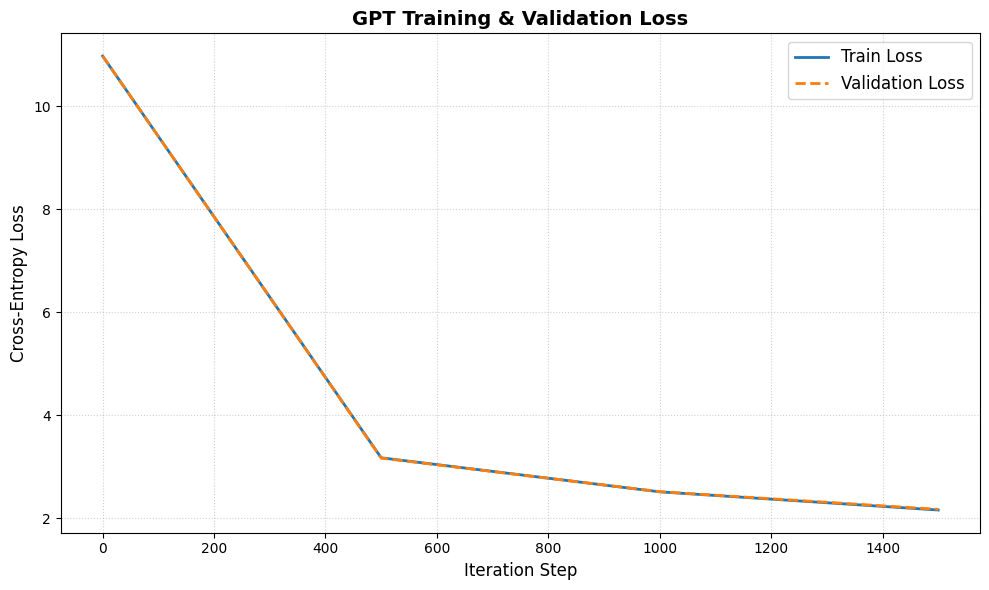

Plot saved to /content/drive/MyDrive/DiffusionLLMs/training_curvetinystories.png
Training complete.
Test Loss: 2.1658 | Perplexity: 8.72

[Final Evaluation] Test Loss: 2.1658 | Perplexity: 8.72


In [35]:
if __name__ == "__main__":
    batch_size = 32
    block_size = 128
    gradient_accumulation_steps = 32
    #learning_rate = 5e-4
    learning_rate = 2e-4
    max_iters = 1500
    #max_iters = 7500
    #max_iters = 1500
    eval_iters = 100
    dataset_dir = work_dir
    dataset_name = "wiki"

    if dataset_train_wiki == True:
        dataset_name = "wiki"
        device, dtype, ctx, scaler = get_device_and_precision()
        config_data=get_config()
        gpt_model=init_model(config_data)
        gpt_model.to(device)
        trained_model = train(
          model=gpt_model,
          device=device,
          ctx=ctx,
          scaler=scaler,
          config_data=config_data,
          batch_size=batch_size,
          block_size=block_size,
          gradient_accumulation_steps=gradient_accumulation_steps,
          learning_rate=learning_rate,
          max_iters=max_iters,
          dataset_dir=dataset_dir,
          dataset_name=dataset_name
        )

        # Evaluate model on test set
        test_loss, perplexity = evaluate_test_set(
        model=trained_model,
          dataset_dir=dataset_dir,
          dataset_name=dataset_name,
          block_size=block_size,
          batch_size=batch_size,
          eval_iters=eval_iters,
          device=device,
          ctx=ctx
        )
        print("Dataset Name ",dataset_name," \n")
        print(f"\n[Final Evaluation] Test Loss: {test_loss:.4f} | Perplexity: {perplexity:.2f}")

    ### Switch to tinystories
    if dataset_train_tinystories == True:
      dataset_name = "tinystories"
      print("Dataset Name ",dataset_name," \n")
      device, dtype, ctx, scaler = get_device_and_precision()
      config_data=get_config()
      gpt_model=init_model(config_data)
      gpt_model.to(device)


      trained_model = train(
          model=gpt_model,
          device=device,
          ctx=ctx,
          scaler=scaler,
          config_data=config_data,
          batch_size=batch_size,
          block_size=block_size,
          gradient_accumulation_steps=gradient_accumulation_steps,
          learning_rate=learning_rate,
          max_iters=max_iters,
          dataset_dir=dataset_dir,
          dataset_name=dataset_name
      )

      # Evaluate test loss & compute Perplexity
      test_loss, perplexity = evaluate_test_set(
          model=trained_model,
          dataset_dir=dataset_dir,
          dataset_name=dataset_name,
          block_size=block_size,
          batch_size=batch_size,
          eval_iters=eval_iters,
          device=device,
          ctx=ctx
      )
      print(f"\n[Final Evaluation] Test Loss: {test_loss:.4f} | Perplexity: {perplexity:.2f}")



**bold text** Train and test tiny stories

In [36]:
if dataset_train_tinystories == True:
  test_prompts = [
        "Once upon a time, there was a tiny dog named",
        "Lily found a magic key in the garden.",
        "One sunny day, Tim went to the store to buy"
  ]
  max_seq_len=config_data['llm_config']['max_seq_len']
  print("\n--- Model Output Generations ---")
  for prompt in test_prompts:
        completion = generate_reponse_prompt(
            model=trained_model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=80,
            temperature=0.7,
            device=device
        )
        print(f"\nPrompt: {prompt}\nGenerated Response:\n{completion}\n" + "-"*40)


--- Model Output Generations ---

Prompt: Once upon a time, there was a tiny dog named
Generated Response:
Once upon a time, there was a tiny dog named Max. He lived in a small house with his owner, Lucy. They all loved to play together at the park. One day, they saw a big tree and wanted to climb it.

"Look at my swing," said Jill. "Let's climb it again!"

So they climbed up the ladder and climbed over it. It looked so pretty! They sat down on a bench
----------------------------------------

Prompt: Lily found a magic key in the garden.
Generated Response:
Lily found a magic key in the garden. She took out her box and put it inside. Inside, she saw a big red door that was open! Lily was so happy to see all of the shiny things inside.

But then, something bad happened. The door opened and Lily's mom came into the room. She had an idea. "What's wrong, my dear?" she asked. Lily told her about the secret and how
----------------------------------------

Prompt: One sunny day, Tim went t